# **PRACTICAL - 5**

## **Aim: Comprehensive House Price Analysis Project**

### **Objective:**
To perform a full exploratory data analysis (EDA) on a housing dataset to identify key drivers of house prices and build a basic predictive model.
Syllabus Topics Covered: Data Cleaning (missing values, outliers), Descriptive Statistics, Univariate & Bivariate Analysis, Feature Selection (correlation), Regression Analysis (Simple and Multiple).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Import Libraries**

**To handle data, visualize graphs, and build regression models.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set(style="whitegrid")

### **1 : Load Dataset**

In [ ]:
import os

os.listdir('/content')


['.config', 'drive', 'melb_data.csv', 'sample_data']

In [ ]:
# Download dataset
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

# Load CSV
file_path = os.path.join(path, "melb_data.csv")
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()


Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Dataset Shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


### **2 : Dataset Overview**

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

### **3 : Data Cleaning**
**Check missing:**

In [ ]:
df.isnull().sum()


,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


### **4 : Descriptive Statistics**

In [ ]:
df.describe()


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


**Key stats for Price:**

In [ ]:
df['Price'].mean()
df['Price'].median()
df['Price'].std()
df['Price'].max() - df['Price'].min()


8915000.0

### **5 : UNIVARIATE ANALYSIS**
**Histogram (Price Distribution)**

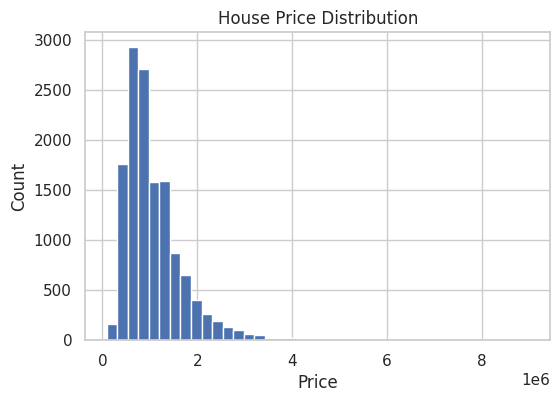

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df['Price'], bins=40)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


### **6 : Boxplot (Outliers)**

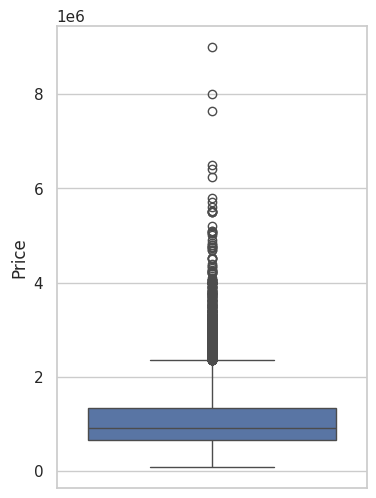

In [ ]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df['Price'])
plt.show()


### **7 : BIVARIATE ANALYSIS**
**Scatter Relationships**

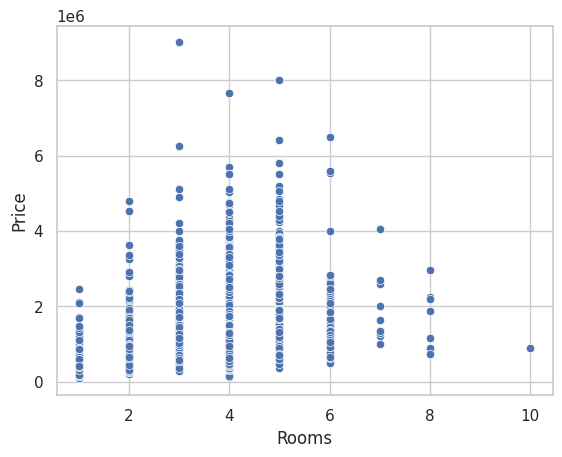

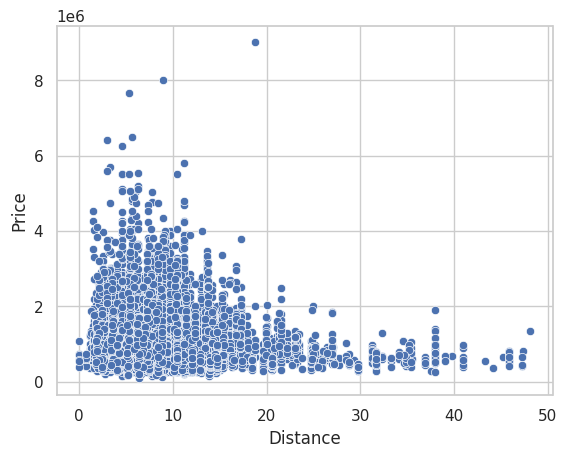

In [ ]:
sns.scatterplot(x=df['Rooms'], y=df['Price'])
plt.show()

sns.scatterplot(x=df['Distance'], y=df['Price'])
plt.show()


### **8 : FEATURE SELECTION**
**Correlation Heatmap**

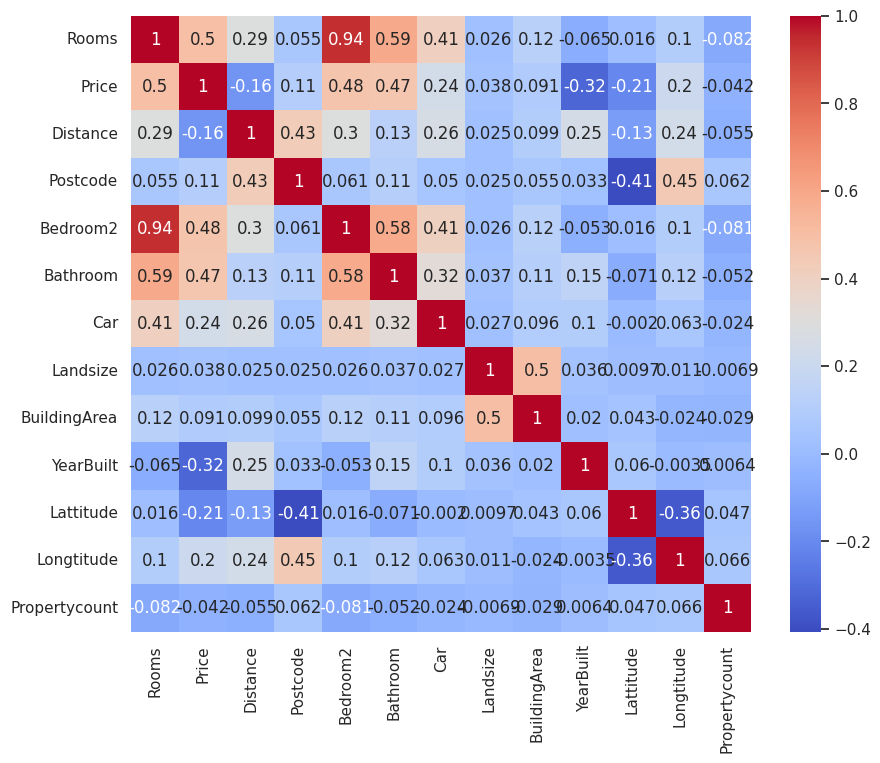

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')   # keep only numbers

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.show()


### **9 : Top Correlated Features**

In [ ]:
df.select_dtypes(include='number').corr()['Price'].sort_values(ascending=False)


,Price
Price,1.000000
Rooms,0.496634
Bedroom2,0.475951
Bathroom,0.467038
Car,0.238979
Longtitude,0.203656
Postcode,0.107867
BuildingArea,0.090981
Landsize,0.037507
Propertycount,-0.042153


### **10 : Simple Linear Regression (1 Feature)**

**Using Rooms:**

In [ ]:
X = df[['Rooms']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

r2_simple = r2_score(y_test, y_pred_simple)
r2_simple


0.23516001527198627

### **11 : Multiple Linear Regression**

In [ ]:
features = ['Rooms','BuildingArea','Bathroom','Car','Landsize']

# Remove rows with missing values
df_clean = df[features + ['Price']].dropna()

X = df_clean[features]
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

y_pred_multi = model_multi.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
print(r2_multi)

0.3482224485222558


In [ ]:
df[features].isna().sum()

,0
Rooms,0
BuildingArea,6450
Bathroom,0
Car,62
Landsize,0


### **12 : Model Comparison**

In [ ]:
print("Simple Model R²:", r2_simple)
print("Multiple Model R²:", r2_multi)


Simple Model R²: 0.23516001527198627
Multiple Model R²: 0.3482224485222558


## **Conclusion**

The housing dataset was analyzed using EDA, correlation analysis, and regression models to identify key factors affecting house prices. Multiple linear regression using selected features provided better prediction performance compared to simple linear regression.

## **Learning Outcomes**

- Understand how to perform data cleaning and handle missing values in a real-world dataset.

- Apply descriptive statistics and visualization techniques to explore data distributions and detect outliers.

- Analyze correlations between variables to identify important features affecting house prices.

- Build and evaluate simple and multiple linear regression models for predicting house prices.

- Compared model performance using R² score